### Practice Exercise (linear Regression)

In [63]:
from pathlib import Path
import sys

current_dir = Path.cwd()
project_root = current_dir.parent.absolute()

sys.path.insert(0,str(project_root))

from config import S_LN

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [65]:
#loading the dataset
df = pd.read_csv(S_LN)

print(f'shape of the dataset: {df.shape}')
print(f'\nMissing values in each columns:\n {df.isnull().sum()}')

shape of the dataset: (30, 2)

Missing values in each columns:
 YearsExperience    0
Salary             0
dtype: int64


In [66]:
print(f'Dataset: \n{df.head()}')

Dataset: 
   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891


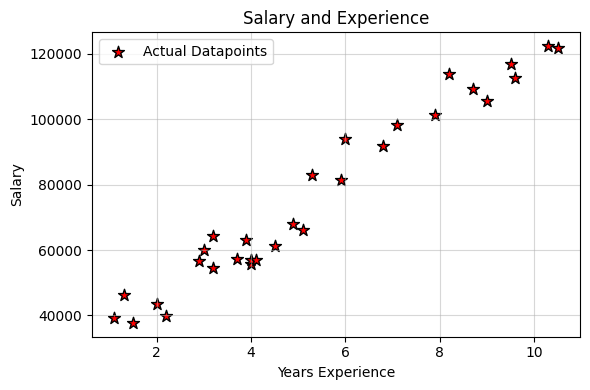

In [67]:
#visualize the experience and Salary in scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df['YearsExperience'],df['Salary'],color='r',marker='*',s=80,edgecolor='black',label='Actual Datapoints')
plt.ylabel('Salary')
plt.xlabel('Years Experience')
plt.grid(True,alpha=0.5)
plt.title('Salary and Experience')
plt.tight_layout()
plt.legend()
plt.show()

In [68]:
#spliting the sets
from sklearn.model_selection import train_test_split

X = df[['YearsExperience']].values
y = df[['Salary']].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [69]:
from sklearn.linear_model import LinearRegression

regressor =  LinearRegression()
regressor.fit(X_train,y_train)

#making prediction
y_pred = regressor.predict(X_train)
y_pred_test = regressor.predict(X_test)

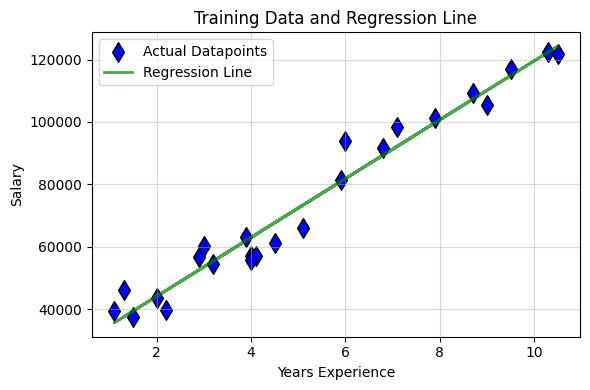

In [70]:
#visualize of the regression line on training set

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, marker='d',color='blue',s=100, edgecolor='black',label='Actual Datapoints')
plt.plot(X_train,y_pred,color='green',alpha=0.7, linewidth=2,label='Regression Line')
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.grid(True, alpha=0.5)
plt.title('Training Data and Regression Line')
plt.legend()
plt.tight_layout()
plt.show()

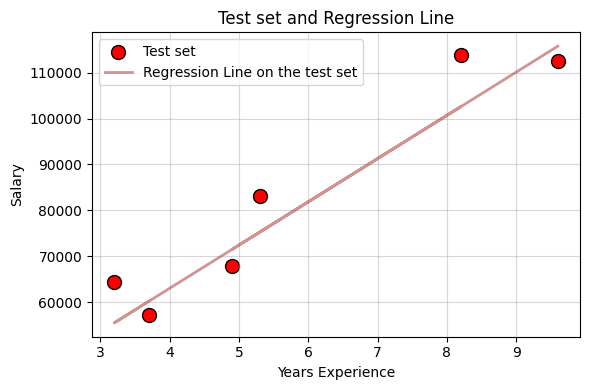

In [71]:
# visualize on the test set plus regression line
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test, color='r',edgecolor='black',s=100,label='Test set')
plt.plot(X_test,y_pred_test,color='brown',linewidth=2,alpha=0.5,label='Regression Line on the test set')
plt.title('Test set and Regression Line')
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.grid(True,alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
#evalution of the model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

R2_score = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
mse = mean_squared_error(y_test,y_pred_test)

print(f'R2_score: {R2_score:.4f}')
print(f'Mean Absolute Error: {mae:.4f}')
print(f'Mean Squared Error: {mse:.4f}')

R2_score: 0.9024
Mean Absolute Error: 6286.4538
Mean Squared Error: 49830096.8559


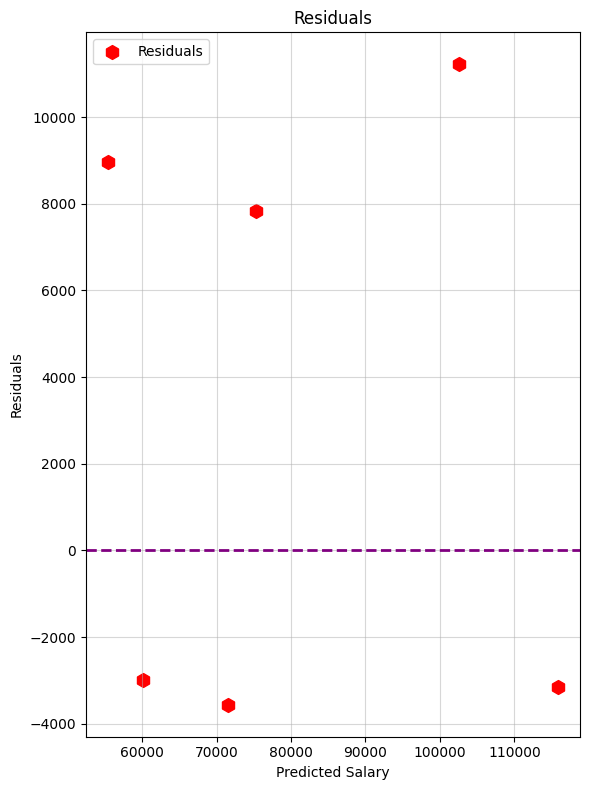

In [73]:
#residuals
residuals = y_test - y_pred_test
plt.figure(figsize=(6,8))
plt.scatter(y_pred_test, residuals,color='r',marker='h',label='Residuals',s=100)
plt.axhline(y=0,color='purple',linestyle='--',linewidth=2)
plt.grid(True,alpha=0.5)
plt.xlabel('Predicted Salary')
plt.ylabel('Residuals')
plt.title('Residuals')
plt.tight_layout()
plt.legend()
plt.show()